In [1]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
# Load dataset
df =  pd.read_csv('winequality-red.csv', sep=';')
  # Update path if needed

# Check for missing values
print(df.isnull().sum())

# Split features/target
X = df.drop('quality', axis=1)
y = df['quality']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [7]:
# Polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)



In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear Regression RMSE: 0.624519930798013


In [9]:
sgd = SGDRegressor(max_iter=10, tol=1e-3, random_state=42)
sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)
print("SGDRegressor RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sgd)))


SGDRegressor RMSE: 0.6253706818487755


In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)
y_pred_ridge = ridge.predict(X_test_poly)
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


Ridge RMSE: 0.6174066319087733


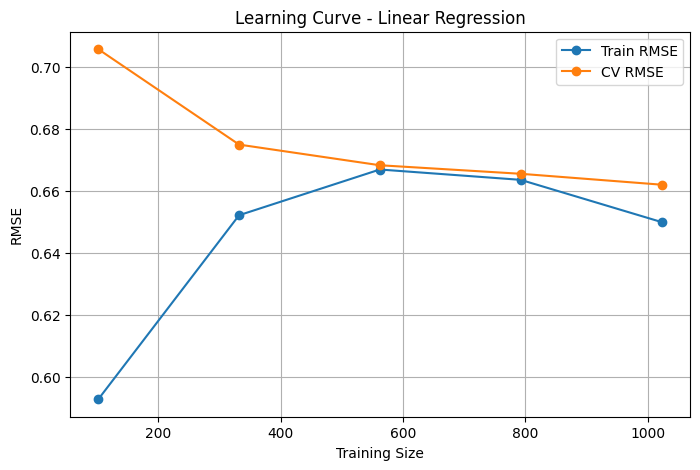

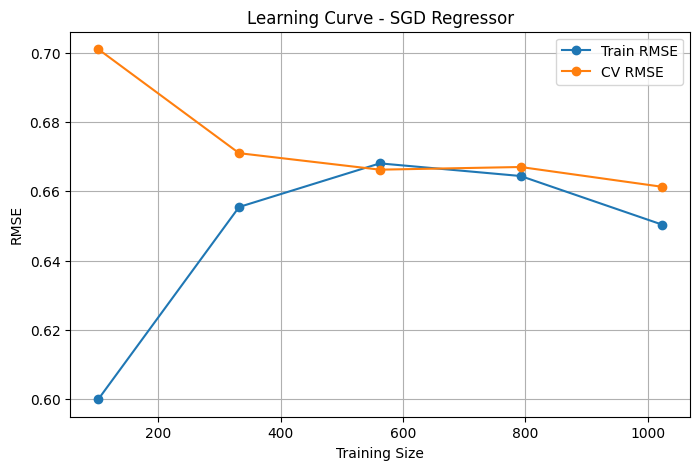

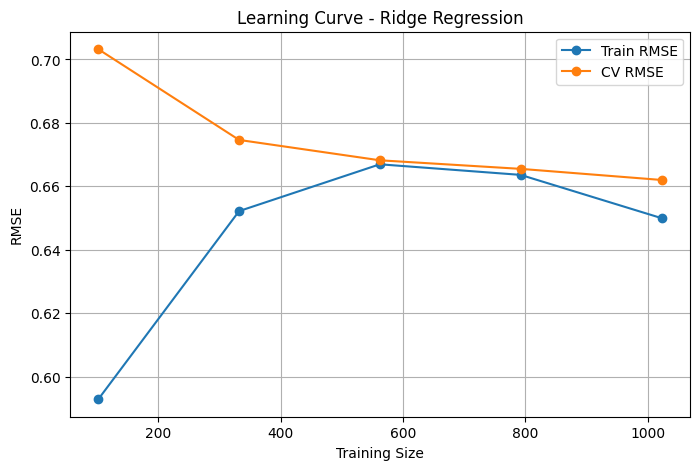

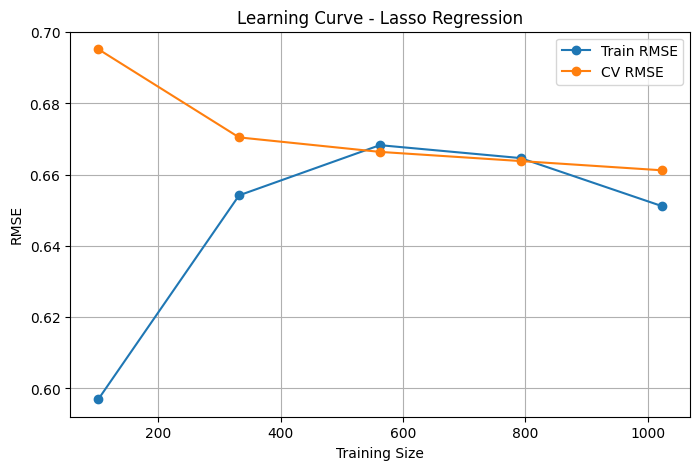

In [11]:
def plot_learning(estimator, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_train, y_train, cv=5, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
    )
    train_rmse = np.sqrt(-train_scores)
    test_rmse = np.sqrt(-test_scores)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_rmse.mean(axis=1), 'o-', label="Train RMSE")
    plt.plot(train_sizes, test_rmse.mean(axis=1), 'o-', label="CV RMSE")
    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid()
    plt.show()

plot_learning(LinearRegression(), "Learning Curve - Linear Regression")
plot_learning(SGDRegressor(max_iter=1000, tol=1e-3), "Learning Curve - SGD Regressor")
plot_learning(Ridge(alpha=1.0), "Learning Curve - Ridge Regression")
plot_learning(Lasso(alpha=0.01), "Learning Curve - Lasso Regression")


In [12]:
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}
grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, scoring='neg_mean_squared_error', cv=5)
grid_ridge.fit(X_train_poly, y_train)

best_ridge = grid_ridge.best_estimator_
print("Best Ridge alpha:", grid_ridge.best_params_)
print("Tuned Ridge RMSE:", np.sqrt(mean_squared_error(y_test, best_ridge.predict(X_test_poly))))


Best Ridge alpha: {'alpha': 100.0}
Tuned Ridge RMSE: 0.6127767761982036


In [19]:
from sklearn.linear_model import Lasso

# Reuse polynomial features
lasso = Lasso(alpha=0.01, max_iter=10)
lasso.fit(X_train_poly, y_train)

# Now you can access lasso.coef_


c:\Users\ASC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.592e+01, tolerance: 8.321e-02
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.01, max_iter=10)

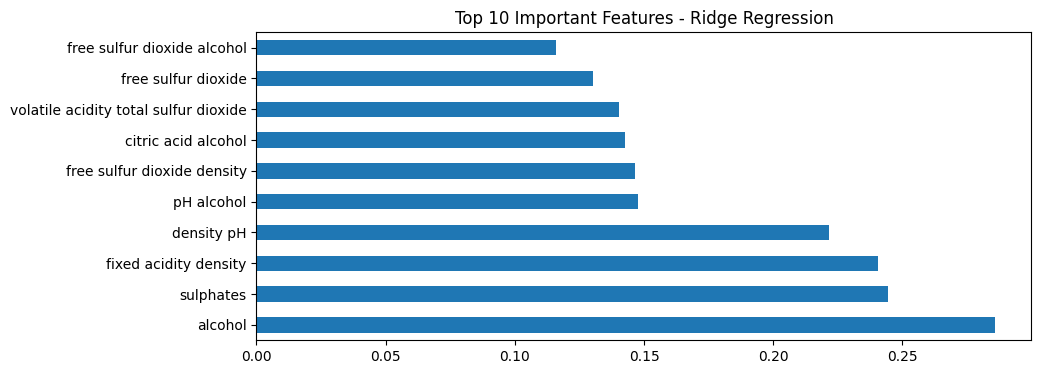

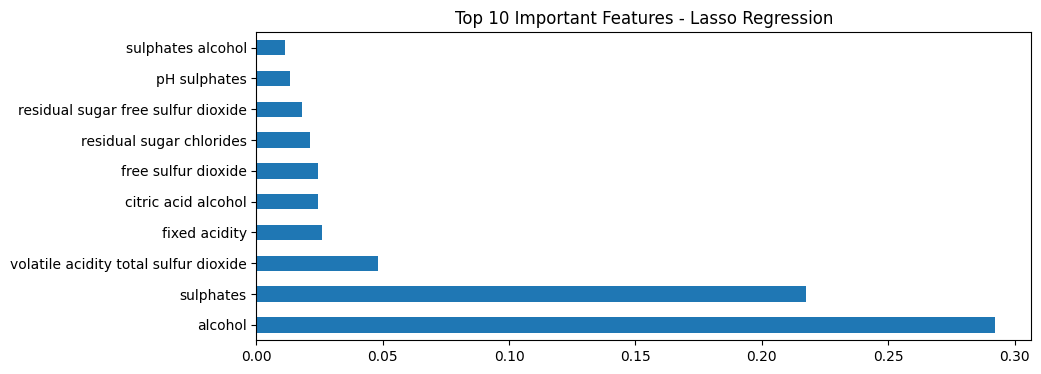

In [20]:

# Feature names from polynomial expansion
feature_names = poly.get_feature_names_out(input_features=X.columns)

# Get importance from coefficients
importance_ridge = pd.Series(ridge.coef_, index=feature_names).sort_values(ascending=False)
importance_lasso = pd.Series(lasso.coef_, index=feature_names).sort_values(ascending=False)

# Plot top 10 important features
plt.figure(figsize=(10, 4))
importance_ridge.head(10).plot(kind='barh')
plt.title("Top 10 Important Features - Ridge Regression")
plt.show()

plt.figure(figsize=(10, 4))
importance_lasso.head(10).plot(kind='barh')
plt.title("Top 10 Important Features - Lasso Regression")
plt.show()


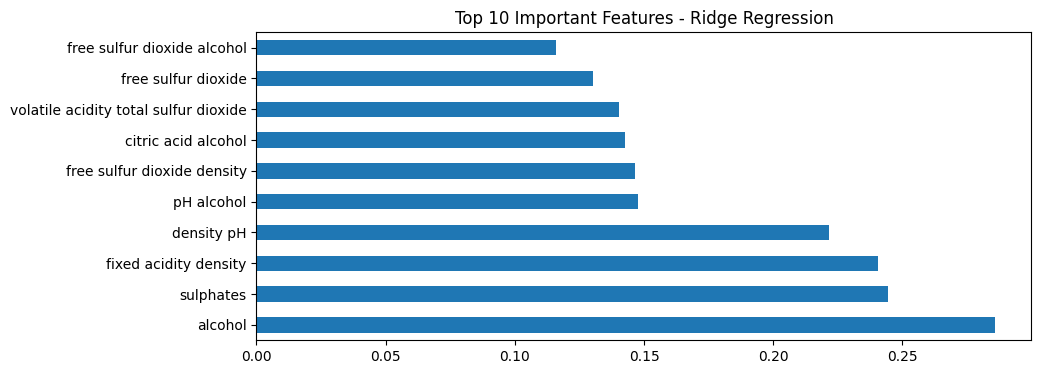

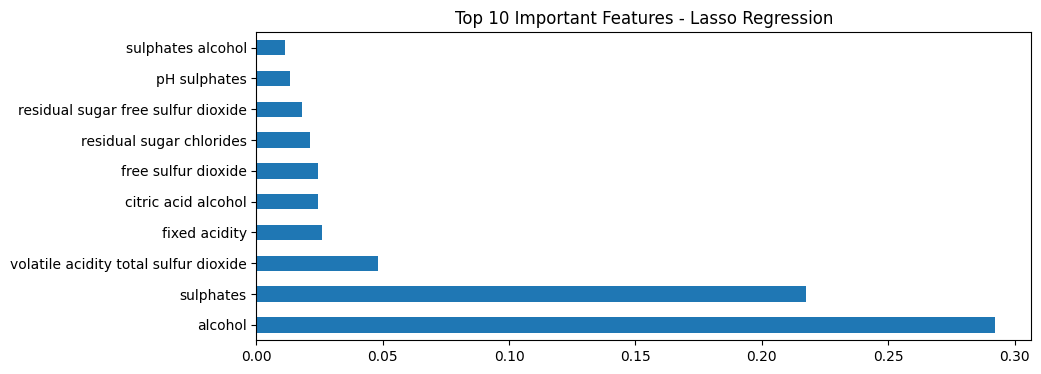

In [21]:
# Get feature names from polynomial transformer
feature_names = poly.get_feature_names_out(input_features=X.columns)

# Feature importance
importance_ridge = pd.Series(ridge.coef_, index=feature_names).sort_values(ascending=False)
importance_lasso = pd.Series(lasso.coef_, index=feature_names).sort_values(ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 4))
importance_ridge.head(10).plot(kind='barh')
plt.title("Top 10 Important Features - Ridge Regression")
plt.show()

plt.figure(figsize=(10, 4))
importance_lasso.head(10).plot(kind='barh')
plt.title("Top 10 Important Features - Lasso Regression")
plt.show()


# Excercise 12

In [22]:
import numpy as np

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(np.log(y_pred[range(m), y_true])) / m

def one_hot(y, num_classes):
    one_hot_matrix = np.zeros((len(y), num_classes))
    one_hot_matrix[np.arange(len(y)), y] = 1
    return one_hot_matrix

def softmax_regression(X, y, lr=0.1, epochs=200, early_stop_rounds=5):
    m, n = X.shape
    k = len(np.unique(y))
    y_one_hot = one_hot(y, k)

    W = np.zeros((n, k))
    b = np.zeros((1, k))

    best_loss = float('inf')
    no_improve = 0

    for epoch in range(epochs):
        logits = np.dot(X, W) + b
        probs = softmax(logits)

        loss = compute_loss(y, probs)

        if loss < best_loss:
            best_loss = loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= early_stop_rounds:
                print(f"Early stopped at epoch {epoch}")
                break

        # Gradient
        dlogits = (probs - y_one_hot) / m
        dW = np.dot(X.T, dlogits)
        db = np.sum(dlogits, axis=0, keepdims=True)

        # Update
        W -= lr * dW
        b -= lr * db

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: loss = {loss:.4f}")

    return W, b
